In [1]:
import struct
from pathlib import Path
import matplotlib.pyplot as plt
import os
import PIL.Image as Image
import numpy as np
import torch.optim as optim
import torchinfo
import matplotlib.colors as mcolors
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch
import torch.nn as nn

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


#### Dataset preparation, loading and visualization

##### Dataset class for preloading and resizing data
For optimization, we will preload and resize all images into RAM.

*read_flo_file* reads the .flo binary format:
[4 bytes magic number] [4 bytes width] [4 bytes height] [rest: flow data float32]

In [3]:
class FlyingChairsPreloadedDataset(Dataset):
    def __init__(self, subset, root='./FlyingChairsData',
                 split_file='./FlyingChairs_train_val.txt', resize=(128, 96), preloading_device='cpu'):
        self.root = Path(root)
        self.resize = resize
        self.preloading_device = preloading_device
        self.pairs = []

        all_flo_files = sorted(self.root.rglob('*_flow.flo'))
        all_ids = [int(file.stem.split('_')[0]) for file in all_flo_files]

        if subset in ('train', 'val'):
            with open(split_file, 'r') as file:
                labels = [int(line.strip()) for line in file.readlines()]
            target = 1 if subset == 'train' else 2
            ids = [datasetId for datasetId, label in zip(all_ids, labels) if label == target]
        else:
            raise ValueError('subset must be either train or val')

        print(f'[{subset}] Preloading {len(ids)} samples into RAM...')

        for i, datasetId in enumerate(ids):
            image1 = self.load_image(self.root / f'{datasetId:05d}_img1.ppm')
            image2 = self.load_image(self.root / f'{datasetId:05d}_img2.ppm')
            flow = self.read_flo_file(self.root / f'{datasetId:05d}_flow.flo')

            image1, image2, flow = self.resize_data(image1, image2, flow)

            image1 = self.to_tensor(image1)
            image2 = self.to_tensor(image2)
            flow = self.to_tensor(flow)

            self.pairs.append((image1, image2, flow))

            if (i + 1) % 1000 == 0:
                print(f'  {i + 1}/{len(ids)} loaded...')

        print(f'[{subset}] Done.')

    def read_flo_file(self, filepath: Path) -> np.ndarray:
        with open(filepath, 'rb') as file:
            magic_num = struct.unpack('f', file.read(4))[0]
            if magic_num != 202021.25:
                raise ValueError('Magic number mismatch — not a valid .flo file')
            width = struct.unpack('i', file.read(4))[0]
            height = struct.unpack('i', file.read(4))[0]
            flow = np.frombuffer(file.read(), dtype=np.float32).reshape((height, width, 2))
        return flow

    def load_image(self, path) -> np.ndarray:
        image = Image.open(path).convert('RGB')
        return np.array(image, dtype=np.float32) / 255.0

    def resize_data(self, image1, image2, flow):
        new_W, new_H = self.resize
        old_H, old_W = image1.shape[:2]
        image1 = cv2.resize(image1, (new_W, new_H))
        image2 = cv2.resize(image2, (new_W, new_H))
        flow = cv2.resize(flow, (new_W, new_H))
        flow[..., 0] *= new_W / old_W
        flow[..., 1] *= new_H / old_H
        return image1, image2, flow

    def to_tensor(self, x):
        return torch.from_numpy(x.transpose(2, 0, 1)).to(self.preloading_device) # H W C -> C H W

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        return self.pairs[idx]

#### Helper functions for visualization

flow[..., 0] = u (x direction), flow[..., 1] = v (y direction)

HSV mapping:
- Hue = direction of movement
- Saturation = speed (magnitude)
- Value = fixed brightness

In [4]:
def convert_flow_to_polar(flow: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    u = flow[0]
    v = flow[1]
    magnitude = np.sqrt(u ** 2 + v ** 2)
    angle = np.arctan2(v, u)
    return magnitude, angle


def map_to_hsv(magnitude, angle, value=0.999) -> np.ndarray:
    hue = (angle + np.pi) / (2 * np.pi)
    saturation = magnitude / (magnitude.max() + 1e-5)
    H, W = magnitude.shape
    hsv = np.zeros((H, W, 3), dtype=np.float32)
    hsv[..., 0] = hue # kot smer
    hsv[..., 1] = saturation # moc hitrost premika ce se pocasi premika je slaba barva
    hsv[..., 2] = value # svetlost
    rgb = mcolors.hsv_to_rgb(hsv)
    return rgb


def visualize_flow(image1, image2, flow):
    magnitude, angle = convert_flow_to_polar(flow.numpy())
    flow_rgb = map_to_hsv(magnitude, angle)
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    axes[0].imshow(image1.numpy().transpose(1, 2, 0))
    axes[0].set_title('Frame 1')
    axes[1].imshow(image2.numpy().transpose(1, 2, 0))
    axes[1].set_title('Frame 2')
    axes[2].imshow(flow_rgb)
    axes[2].set_title('Optical Flow (HSV)')
    plt.tight_layout()
    plt.show()


def visualize_flow_multiscale(flow, num_levels=6):
    flow_levels = []
    current_flow = flow.unsqueeze(0).float()
    for i in range(num_levels):
        H, W = current_flow.shape[2], current_flow.shape[3]
        flow_levels.append(current_flow[0])
        if i < num_levels - 1:
            new_H, new_W = H // 2, W // 2
            current_flow = torch.nn.functional.interpolate(
                current_flow, size=(new_H, new_W), mode='bilinear', align_corners=False
            )
            current_flow[:, 0] *= new_W / W
            current_flow[:, 1] *= new_H / H
    fig, axes = plt.subplots(1, num_levels, figsize=(4 * num_levels, 4))
    for i, f in enumerate(flow_levels):
        H, W = f.shape[1], f.shape[2]
        magnitude, angle = convert_flow_to_polar(f.numpy())
        flow_rgb = map_to_hsv(magnitude, angle)
        axes[i].imshow(flow_rgb, interpolation='nearest')
        axes[i].set_title(f'Flow ({H}, {W})')
        axes[i].set_axis_off()
    plt.tight_layout()
    plt.show()

[train] Preloading 22232 samples into RAM...
  1000/22232 loaded...
  2000/22232 loaded...
  3000/22232 loaded...
  4000/22232 loaded...
  5000/22232 loaded...
  6000/22232 loaded...
  7000/22232 loaded...
  8000/22232 loaded...
  9000/22232 loaded...
  10000/22232 loaded...
  11000/22232 loaded...
  12000/22232 loaded...
  13000/22232 loaded...
  14000/22232 loaded...
  15000/22232 loaded...
  16000/22232 loaded...
  17000/22232 loaded...
  18000/22232 loaded...
  19000/22232 loaded...
  20000/22232 loaded...
  21000/22232 loaded...
  22000/22232 loaded...
[train] Done.
[val] Preloading 640 samples into RAM...
[val] Done.
torch.Size([8, 3, 96, 128])
torch.Size([8, 3, 96, 128])
torch.Size([8, 2, 96, 128])


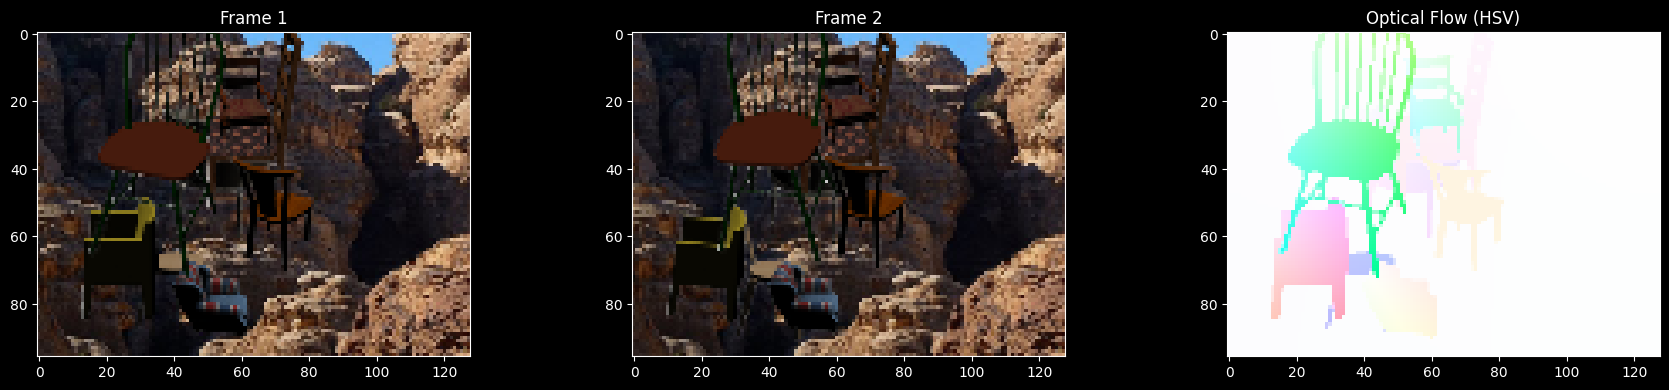

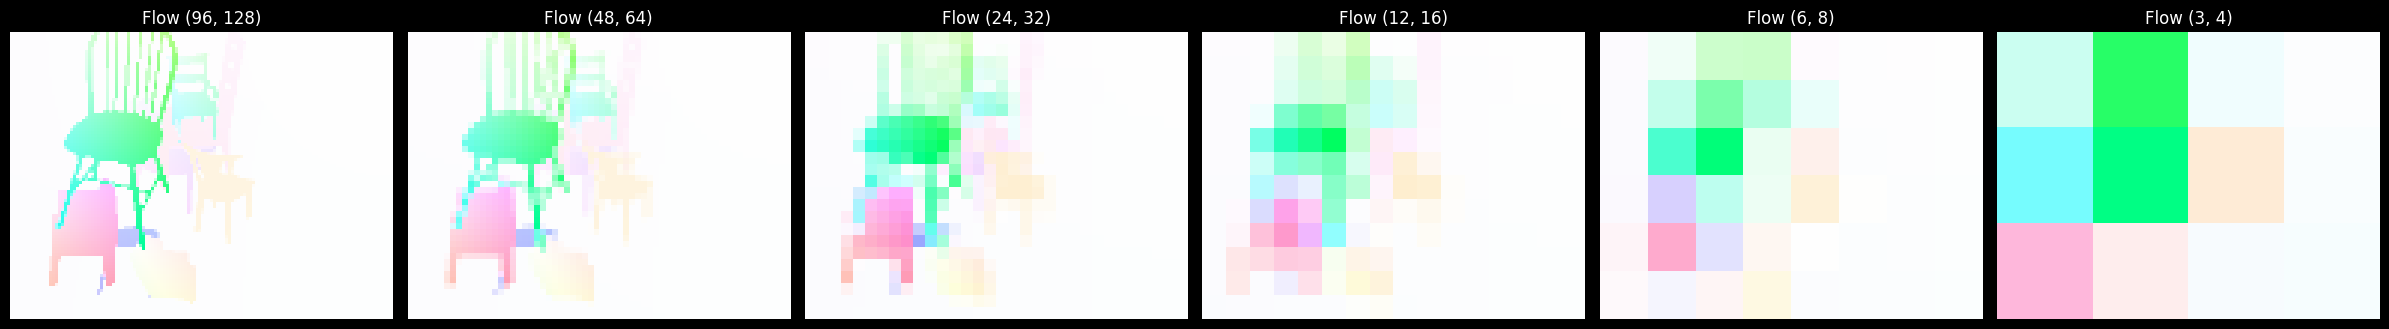

In [5]:
train_set = FlyingChairsPreloadedDataset(subset='train')
val_set = FlyingChairsPreloadedDataset(subset='val')

train_loader = DataLoader(train_set, batch_size=8, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=8, shuffle=False, num_workers=0, pin_memory=True)

img1_batch, img2_batch, flow_batch = next(iter(train_loader))
print(img1_batch.shape)
print(img2_batch.shape)
print(flow_batch.shape)

sample_image1 = img1_batch[0]
sample_image2 = img2_batch[0]
sample_flow = flow_batch[0]

visualize_flow(sample_image1, sample_image2, sample_flow)
visualize_flow_multiscale(sample_flow)

#### FlowNetSimple Neural Network

Encoder-decoder U-Net architecture for optical flow prediction.

##### Encoder

Input: 2 concatenated RGB images (6 channels).
3× DownBlock (Conv-BN-ReLU × 2 + MaxPool) followed by 2× bottleneck Conv-BN-ReLU.

In [6]:
class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size):
        super().__init__()
        self.convolution_block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, padding=kernel_size // 2),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size, padding=kernel_size // 2),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        skip = self.convolution_block(x)
        out = self.pool(skip)
        return out, skip

In [7]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.downBlock1 = DownBlock(in_channels=6,   out_channels=32,  kernel_size=7)
        self.downBlock2 = DownBlock(in_channels=32,  out_channels=64,  kernel_size=5)
        self.downBlock3 = DownBlock(in_channels=64,  out_channels=128, kernel_size=3)
        self.bottleneck = nn.Sequential(
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        out1, skip1 = self.downBlock1(x)
        out2, skip2 = self.downBlock2(out1)
        out3, skip3 = self.downBlock3(out2)
        bottleneck = self.bottleneck(out3)
        return bottleneck, skip1, skip2, skip3

##### Decoder

Multi-scale decoder with skip connections and flow predictions at each level:
- Level 4 (32×32):   bottleneck 256ch → predict flow (2ch)
- Level 3 (64×64):   deconv 256→128, cat skip3(128) → 256ch, cat flow4_up(2) → 258ch → predict flow
- Level 2 (128×128): deconv 256→64,  cat skip2(64)  → 128ch, cat flow3_up(2) → 130ch → predict flow
- Level 1 (256×256): deconv 128→32,  cat skip1(32)  → 64ch,  cat flow2_up(2) → 66ch  → predict flow

In [8]:
class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Bottleneck prediction (32×32): bottleneck=256ch
        self.predict_flow4 = nn.Conv2d(in_channels=256, out_channels=2, kernel_size=1)
        self.up_flow4 = nn.ConvTranspose2d(in_channels=2, out_channels=2, kernel_size=2, stride=2)

        # Level 3 (64×64): deconv 256→128, cat skip3(128) → 256, cat flow4_up(2) → 258
        self.deconv3 = nn.ConvTranspose2d(in_channels=256, out_channels=128, kernel_size=2, stride=2)
        self.predict_flow3 = nn.Conv2d(in_channels=258, out_channels=2, kernel_size=1)
        self.up_flow3 = nn.ConvTranspose2d(in_channels=2, out_channels=2, kernel_size=2, stride=2)

        # Level 2 (128×128): deconv 256→64, cat skip2(64) → 128, cat flow3_up(2) → 130
        self.deconv2 = nn.ConvTranspose2d(in_channels=256, out_channels=64, kernel_size=2, stride=2)
        self.predict_flow2 = nn.Conv2d(in_channels=130, out_channels=2, kernel_size=1)
        self.up_flow2 = nn.ConvTranspose2d(in_channels=2, out_channels=2, kernel_size=2, stride=2)

        # Level 1 (256×256): deconv 128→32, cat skip1(32) → 64, cat flow2_up(2) → 66
        self.deconv1 = nn.ConvTranspose2d(in_channels=128, out_channels=32, kernel_size=2, stride=2)
        self.predict_flow1 = nn.Conv2d(in_channels=66, out_channels=2, kernel_size=1)

    def forward(self, bottleneck, skip1, skip2, skip3):
        # Bottleneck (32×32)
        flow4    = self.predict_flow4(bottleneck)            # (B,   2,  32,  32)
        flow4_up = self.up_flow4(flow4)                      # (B,   2,  64,  64)

        # Level 3 (64×64)
        up_feat3 = self.deconv3(bottleneck)                  # (B, 128,  64,  64)
        feat3    = torch.cat([up_feat3, skip3], dim=1)       # (B, 256,  64,  64)
        concat3  = torch.cat([feat3, flow4_up], dim=1)       # (B, 258,  64,  64)
        flow3    = self.predict_flow3(concat3)               # (B,   2,  64,  64)
        flow3_up = self.up_flow3(flow3)                      # (B,   2, 128, 128)

        # Level 2 (128×128)
        up_feat2 = self.deconv2(feat3)                       # (B,  64, 128, 128)
        feat2    = torch.cat([up_feat2, skip2], dim=1)       # (B, 128, 128, 128)
        concat2  = torch.cat([feat2, flow3_up], dim=1)       # (B, 130, 128, 128)
        flow2    = self.predict_flow2(concat2)               # (B,   2, 128, 128)
        flow2_up = self.up_flow2(flow2)                      # (B,   2, 256, 256)

        # Level 1 (256×256)
        up_feat1 = self.deconv1(feat2)                       # (B,  32, 256, 256)
        feat1    = torch.cat([up_feat1, skip1], dim=1)       # (B,  64, 256, 256)
        concat1  = torch.cat([feat1, flow2_up], dim=1)       # (B,  66, 256, 256)
        flow1    = self.predict_flow1(concat1)               # (B,   2, 256, 256)

        return flow1, flow2, flow3, flow4

##### FlowNetSimple Neural Network

In [9]:
class FlowNetSimple(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def forward(self, image1, image2):
        x = torch.cat([image1, image2], dim=1)
        bottleneck, skip1, skip2, skip3 = self.encoder(x)
        flow1, flow2, flow3, flow4 = self.decoder(bottleneck, skip1, skip2, skip3)
        return flow1, flow2, flow3, flow4

In [10]:
model = FlowNetSimple().to(device)
print(torchinfo.summary(
    model,
    input_size=[(1, 3, 256, 256), (1, 3, 256, 256)],
    device=device,
    depth=4,
    col_names=("input_size", "output_size", "num_params", "mult_adds"),
))

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Mult-Adds
FlowNetSimple                            [1, 3, 256, 256]          [1, 2, 256, 256]          --                        --
├─Encoder: 1-1                           [1, 6, 256, 256]          [1, 256, 32, 32]          --                        --
│    └─DownBlock: 2-1                    [1, 6, 256, 256]          [1, 32, 128, 128]         --                        --
│    │    └─Sequential: 3-1              [1, 6, 256, 256]          [1, 32, 256, 256]         --                        --
│    │    │    └─Conv2d: 4-1             [1, 6, 256, 256]          [1, 32, 256, 256]         9,440                     618,659,840
│    │    │    └─BatchNorm2d: 4-2        [1, 32, 256, 256]         [1, 32, 256, 256]         64                        64
│    │    │    └─ReLU: 4-3               [1, 32, 256, 256]         [1, 32, 256, 256]         --                        --
│    │  

#### Train the model with last or multiple outputs

##### Train and validate with last output only + loss visualization

EPE loss on highest-resolution output (flow1) only.

In [11]:
def epe_last_output_loss(predicted, target) -> torch.Tensor:
    """Mean Euclidean distance between predicted and ground-truth flow."""
    return torch.mean(torch.sqrt(((predicted - target) ** 2).sum(dim=1) + 1e-8))


In [12]:
import time

def train_last_output(model, loader, optimizer, device, current_step, max_steps) -> tuple[float, int]:
    model.train()
    total_loss = 0.0
    steps_done = 0

    # LR decay schedule: halve at steps 200k, 300k, 400k, 500k
    lr_decay_milestones = {200_000, 300_000, 400_000, 500_000}

    for i, (image1, image2, flow) in enumerate(loader):
        if current_step + steps_done >= max_steps:
            break

        image1 = image1.to(device, non_blocking=True)
        image2 = image2.to(device, non_blocking=True)
        flow   = flow.to(device, non_blocking=True)

        t0 = time.perf_counter()

        optimizer.zero_grad()

        with torch.amp.autocast("cuda", enabled=device.type == "cuda", dtype=torch.float16):
            flow1, flow2, flow3, flow4 = model(image1, image2)
            loss = epe_last_output_loss(flow1, flow)

        if torch.isnan(loss):
            print(f"  [NaN skip] step {current_step + steps_done + 1}")
            continue

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        elapsed = time.perf_counter() - t0

        total_loss += loss.item()
        steps_done += 1
        global_step = current_step + steps_done

        # Apply LR decay when crossing a milestone
        if global_step in lr_decay_milestones:
            for g in optimizer.param_groups:
                g['lr'] *= 0.5
            print(f'  [LR decay] step {global_step} -> lr={optimizer.param_groups[0]["lr"]:.2e}')

        print(f'  Step {global_step:>6}/{max_steps} | loss: {loss.item():.4f} | lr: {optimizer.param_groups[0]["lr"]:.2e} | {elapsed:.2f}s/step')

    return total_loss / max(steps_done, 1), steps_done


In [13]:
def validate_last_output(model, loader, device) -> float:
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for i, (image1, image2, flow) in enumerate(loader):
            image1 = image1.to(device, non_blocking=True)
            image2 = image2.to(device, non_blocking=True)
            flow   = flow.to(device, non_blocking=True)

            with torch.amp.autocast("cuda", enabled=device.type == "cuda", dtype=torch.float16):
                flow1, flow2, flow3, flow4 = model(image1, image2)
                loss = epe_last_output_loss(flow1, flow)

            total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

model_single = FlowNetSimple().to(device)
optimizer = optim.Adam(model_single.parameters(), lr=1e-4)
scaler = torch.amp.GradScaler("cuda")

train_losses_last_output = []
val_losses_last_output   = []

step      = 0
max_steps = 500_000

for epoch in range(1, 10000):
    train_loss, steps_done = train_last_output(model_single, train_loader, optimizer, device, step, max_steps)
    val_loss = validate_last_output(model_single, val_loader, device)

    train_losses_last_output.append(train_loss)
    val_losses_last_output.append(val_loss)

    step += steps_done

    if step >= max_steps:
        torch.save({
            'step': step,
            'model_state_dict': model_single.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_losses': train_losses_last_output,
            'val_losses':   val_losses_last_output,
        }, 'flownet_single_final.pth')
        print('  => final single-output model saved')
        break


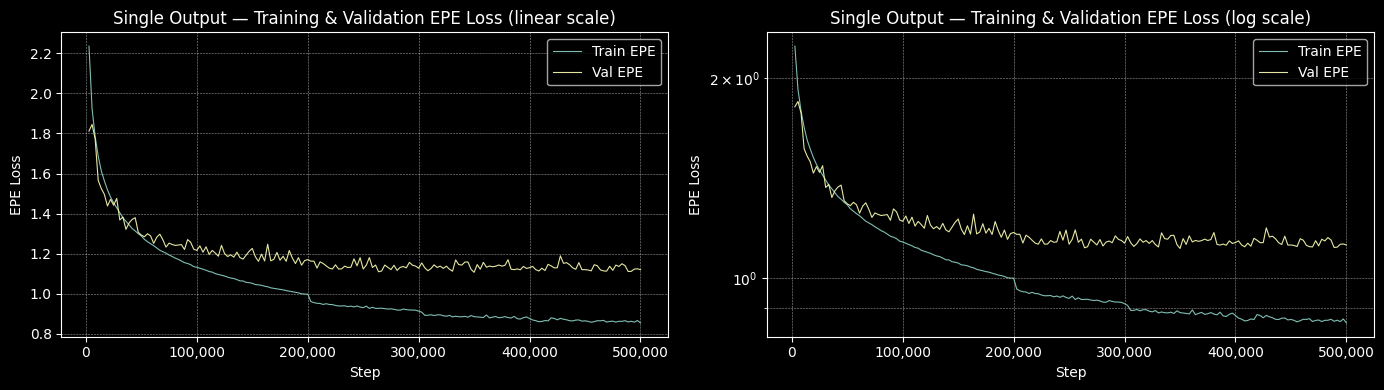

Saved -> visualization/loss_single_output.png


In [15]:

def plot_train_val_loss(is_last_output=False):
    if is_last_output:
        train_losses = train_losses_last_output
        val_losses   = val_losses_last_output
        title        = 'Single Output — Training & Validation EPE Loss'
        out_path     = 'visualization/loss_single_output.png'
        total_steps  = 500_000
    else:
        train_losses = train_losses_multi_output
        val_losses   = val_losses_multi_output
        title        = 'Multi Output — Training & Validation EPE Loss'
        out_path     = 'visualization/loss_multi_outputs.png'
        total_steps  = 500_000

    os.makedirs('visualization', exist_ok=True)

    # Map each epoch entry to its approximate step
    n = len(train_losses)
    steps = [int((i + 1) * total_steps / n) for i in range(n)]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    for ax, yscale in zip(axes, ('linear', 'log')):
        ax.plot(steps, train_losses, label='Train EPE', linewidth=0.8, alpha=0.9)
        ax.plot(steps, val_losses,   label='Val EPE',   linewidth=0.8, alpha=0.9)
        ax.set_yscale(yscale)
        ax.set_title(f'{title} ({yscale} scale)')
        ax.set_xlabel('Step')
        ax.set_ylabel('EPE Loss')
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
        ax.grid(True, which='both', linestyle='--', linewidth=0.4, alpha=0.6)
        ax.legend()

    fig.tight_layout()
    fig.savefig(out_path, dpi=120)
    plt.show()
    print(f'Saved -> {out_path}')

plot_train_val_loss(True)

##### Train with multi-level outputs

EPE is computed at every decoder prediction head at all resolution levels and averaged.

In [16]:
def epe_multi_output_loss(predictions, target) -> torch.Tensor:
    """Weighted sum of EPE losses across all decoder output scales."""
    weights = [1,1,1,1]   # finest -> coarsest
    total_loss = 0.0
    for pred, w in zip(predictions, weights):
        # Downsample target to match this prediction's spatial size
        target_ds = torch.nn.functional.interpolate(
            target,
            size=pred.shape[2:],
            mode='bilinear',
            align_corners=False,
        )
        total_loss = total_loss + w * torch.mean(
            torch.sqrt(((pred - target_ds) ** 2).sum(dim=1) + 1e-8)
        )
    return total_loss


In [17]:
def train_multi_outputs(model, loader, optimizer, device, current_step, max_steps) -> tuple[float, int]:
    model.train()
    total_loss = 0.0
    steps_done = 0

    # LR decay schedule: halve at steps 200k, 300k, 400k, 500k
    lr_decay_milestones = {200_000, 300_000, 400_000, 500_000}

    for i, (image1, image2, flow) in enumerate(loader):
        if current_step + steps_done >= max_steps:
            break

        image1 = image1.to(device, non_blocking=True)
        image2 = image2.to(device, non_blocking=True)
        flow   = flow.to(device, non_blocking=True)

        t0 = time.perf_counter()

        optimizer.zero_grad()

        with torch.amp.autocast("cuda", enabled=device.type == "cuda", dtype=torch.float16):
            predictions = model(image1, image2)
            loss = epe_multi_output_loss(predictions, flow)

        if torch.isnan(loss):
            print(f"  [NaN skip] step {current_step + steps_done + 1}")
            continue

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        elapsed = time.perf_counter() - t0

        total_loss += loss.item()
        steps_done += 1
        global_step = current_step + steps_done

        # Apply LR decay when crossing a milestone
        if global_step in lr_decay_milestones:
            for g in optimizer.param_groups:
                g['lr'] *= 0.5
            print(f'  [LR decay] step {global_step} -> lr={optimizer.param_groups[0]["lr"]:.2e}')

        print(f'  Step {global_step:>6}/{max_steps} | loss: {loss.item():.4f} | lr: {optimizer.param_groups[0]["lr"]:.2e} | {elapsed:.2f}s/step')

    return total_loss / max(steps_done, 1), steps_done


In [18]:
def validate_multi_output(model, loader, device) -> float:
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for i, (image1, image2, flow) in enumerate(loader):
            image1 = image1.to(device, non_blocking=True)
            image2 = image2.to(device, non_blocking=True)
            flow   = flow.to(device, non_blocking=True)

            with torch.amp.autocast("cuda", enabled=device.type == "cuda", dtype=torch.float16):
                predictions = model(image1, image2)
                loss = epe_multi_output_loss(predictions, flow)

            total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

model_multi = FlowNetSimple().to(device)
optimizer = optim.Adam(model_multi.parameters(), lr=1e-4)
scaler = torch.amp.GradScaler("cuda")

train_losses_multi_output = []
val_losses_multi_output   = []

step      = 0
max_steps = 500_000

for epoch in range(1, 10000):
    train_loss, steps_done = train_multi_outputs(model_multi, train_loader, optimizer, device, step, max_steps)
    val_loss = validate_multi_output(model_multi, val_loader, device)

    train_losses_multi_output.append(train_loss)
    val_losses_multi_output.append(val_loss)

    step += steps_done

    if step >= max_steps:
        torch.save({
            'step': step,
            'model_state_dict': model_multi.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_losses': train_losses_multi_output,
            'val_losses':   val_losses_multi_output,
        }, 'flownet_multi_final.pth')
        print('  => final multi-output model saved')
        break


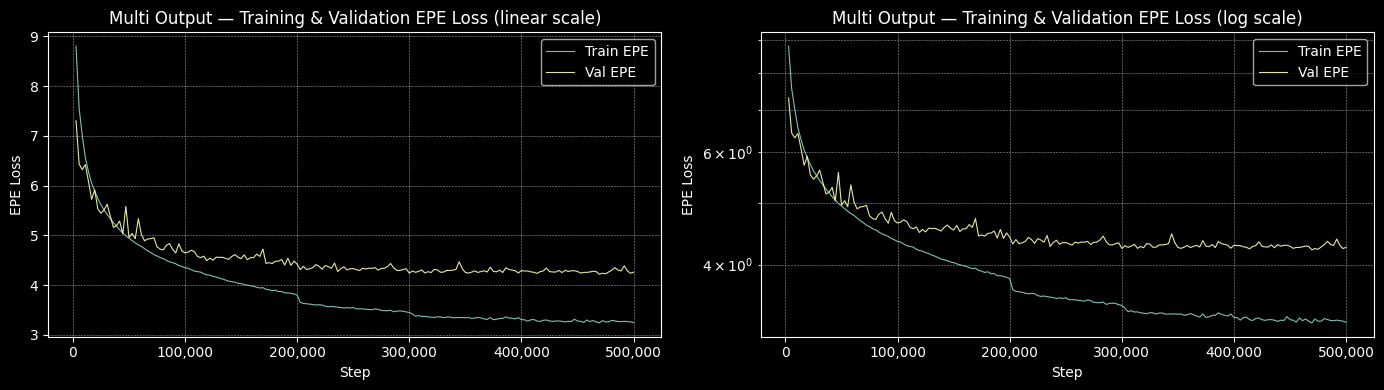

Saved -> visualization/loss_multi_outputs.png


In [20]:
plot_train_val_loss(False)

#### Evaluations

##### On MPI Sintel dataset

In [21]:
class SintelDataset(Dataset):
    def __init__(self, root='./MPI-Sintel-complete', pass_type='clean', resize=(256, 256)):
        self.root = Path(root)
        self.resize = resize
        self.pairs = []

        flow_root  = self.root / 'training' / 'flow'
        image_root = self.root / 'training' / pass_type

        for scene_dir in sorted(p for p in flow_root.iterdir() if p.is_dir()):
            scene = scene_dir.name
            for flo_file in sorted(scene_dir.glob('*.flo')):
                fnum = int(flo_file.stem.split('_')[-1])
                image1 = image_root / scene / f'frame_{fnum:04d}.png'
                image2 = image_root / scene / f'frame_{fnum + 1:04d}.png'
                if image1.exists() and image2.exists():
                    self.pairs.append((image1, image2, flo_file))

        print(f'[Sintel/{pass_type}] Found {len(self.pairs)} pairs')

    def read_flo_file(self, filepath: Path) -> np.ndarray:
        with open(filepath, 'rb') as file:
            magic_num = struct.unpack('f', file.read(4))[0]
            if magic_num != 202021.25:
                raise ValueError('Magic number mismatch — not a valid .flo file')
            width  = struct.unpack('i', file.read(4))[0]
            height = struct.unpack('i', file.read(4))[0]
            flow = np.frombuffer(file.read(), dtype=np.float32).reshape((height, width, 2))
        return flow

    def load_image(self, path) -> np.ndarray:
        return np.array(Image.open(path).convert('RGB'), dtype=np.float32) / 255.0

    def resize_data(self, image1, image2, flow):
        new_W, new_H = self.resize
        old_H, old_W = image1.shape[:2]
        image1 = cv2.resize(image1, (new_W, new_H))
        image2 = cv2.resize(image2, (new_W, new_H))
        flow   = cv2.resize(flow,   (new_W, new_H))
        flow[..., 0] *= new_W / old_W
        flow[..., 1] *= new_H / old_H
        return image1, image2, flow

    def to_tensor(self, x):
        return torch.from_numpy(x.transpose(2, 0, 1))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img1_path, img2_path, flo_path = self.pairs[idx]
        image1 = self.load_image(img1_path)
        image2 = self.load_image(img2_path)
        flow   = self.read_flo_file(flo_path)
        image1, image2, flow = self.resize_data(image1, image2, flow)
        return self.to_tensor(image1), self.to_tensor(image2), self.to_tensor(flow)

[Sintel/clean] Found 1041 pairs
torch.Size([8, 3, 256, 256])
torch.Size([8, 3, 256, 256])
torch.Size([8, 2, 256, 256])


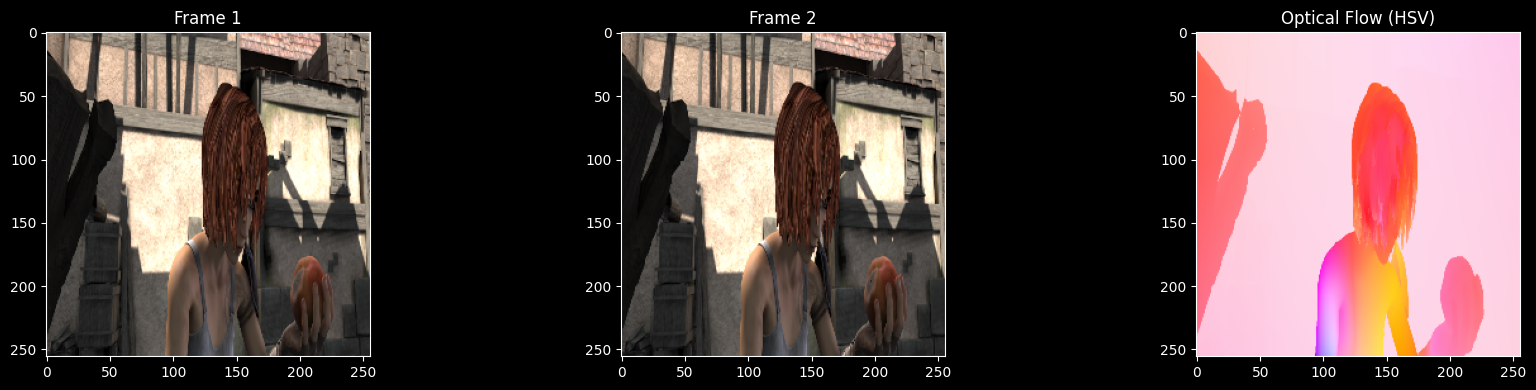

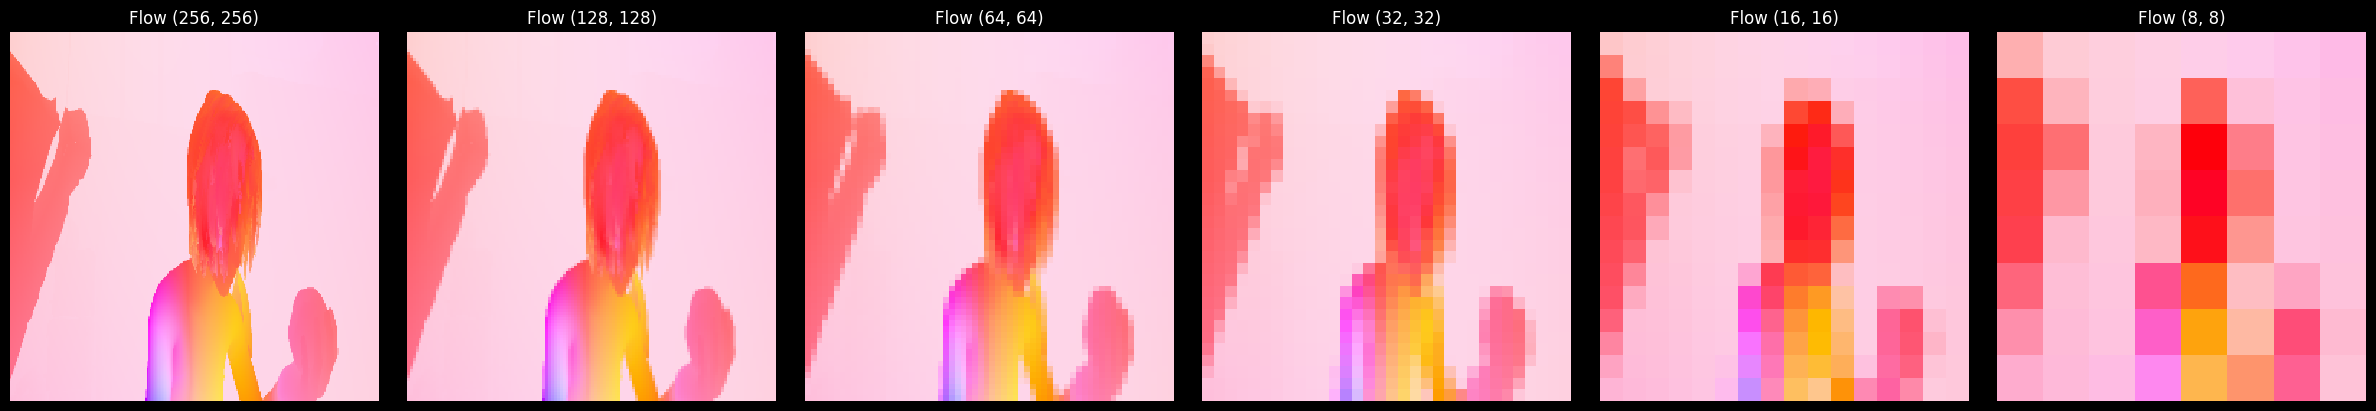

In [22]:
sintel_dataset = SintelDataset()
sintel_loader  = DataLoader(sintel_dataset, batch_size=8, shuffle=False, num_workers=0)

img1_batch, img2_batch, flow_batch = next(iter(sintel_loader))
print(img1_batch.shape)
print(img2_batch.shape)
print(flow_batch.shape)

sample_image1 = img1_batch[0]
sample_image2 = img2_batch[0]
sample_flow   = flow_batch[0]

visualize_flow(sample_image1, sample_image2, sample_flow)
visualize_flow_multiscale(sample_flow)

In [23]:
def evaluate_on_sintel(model, sintel_loader, device) -> float:
    model.eval()
    total_epe = 0.0

    with torch.no_grad():
        for image1, image2, flow in sintel_loader:
            image1 = image1.to(device, non_blocking=True)
            image2 = image2.to(device, non_blocking=True)
            flow   = flow.to(device, non_blocking=True)

            flow1, _, _, _ = model(image1, image2)
            epe = epe_last_output_loss(flow1, flow)
            total_epe += epe.item()

    return total_epe / len(sintel_loader)

In [24]:
# Load trained models
try:
    checkpoint_single = torch.load('flownet_single_final.pth', map_location=device, weights_only=False)
    model_single.load_state_dict(checkpoint_single['model_state_dict'])
    print('model_single loaded.')
except FileNotFoundError:
    print('WARNING: flownet_single_final.pth not found — train model_single first.')

try:
    checkpoint_multi = torch.load('flownet_multi_final.pth', map_location=device, weights_only=False)
    model_multi.load_state_dict(checkpoint_multi['model_state_dict'])
    print('model_multi loaded.')
except FileNotFoundError:
    print('WARNING: flownet_multi_final.pth not found — train model_multi first.')

for pass_type in ('clean', 'final'):
    sintel_dataset    = SintelDataset(pass_type=pass_type, resize=(256, 256))
    sintel_loader_eval = DataLoader(sintel_dataset, batch_size=8, shuffle=False, num_workers=0)
    epe_single = evaluate_on_sintel(model_single, sintel_loader_eval, device)
    epe_multi  = evaluate_on_sintel(model_multi,  sintel_loader_eval, device)
    print(f'[{pass_type}] single: {epe_single:.4f} px | multi: {epe_multi:.4f} px')

model_single loaded.
model_multi loaded.
[Sintel/clean] Found 1041 pairs
[clean] single: 3.2655 px | multi: 3.2163 px
[Sintel/final] Found 1041 pairs
[final] single: 3.4819 px | multi: 3.3896 px


##### On Farneback baseline (OpenCV)

Parameters:
- pyr_scale: pyramid scale (0.5 = half size per level)
- levels: number of pyramid levels
- winsize: averaging window size
- iterations: iterations per pyramid level
- poly_n: neighbourhood size for polynomial expansion (5 or 7)
- poly_sigma: Gaussian sigma for polynomial expansion

In [25]:
import numpy as np
import cv2

def farneback_flow(image1_uint8, image2_uint8, pyr_scale=0.5, levels=3, winsize=15,
                   iterations=3, poly_n=5, poly_sigma=1.2) -> np.ndarray:
    g1 = cv2.cvtColor(image1_uint8, cv2.COLOR_RGB2GRAY)
    g2 = cv2.cvtColor(image2_uint8, cv2.COLOR_RGB2GRAY)
    flow = cv2.calcOpticalFlowFarneback(
        g1, g2, None,
        pyr_scale, levels, winsize, iterations, poly_n, poly_sigma, 0
    )
    return flow

def evaluate_farneback(loader, **fb_kwargs):
    epes = []
    for image1, image2, flow in loader:
        for b in range(image1.shape[0]):
            img1_np = (image1[b].numpy().transpose(1, 2, 0) * 255.0).astype(np.uint8)
            img2_np = (image2[b].numpy().transpose(1, 2, 0) * 255.0).astype(np.uint8)
            gt      = flow[b].numpy().transpose(1, 2, 0)
            pred    = farneback_flow(img1_np, img2_np, **fb_kwargs)
            epe_map = np.sqrt(((pred - gt) ** 2).sum(axis=-1))
            epes.append(float(epe_map.mean()))
    epes = np.array(epes)
    return float(epes.mean()), float(epes.std()), epes

In [26]:
configs = [
    dict(pyr_scale=0.5, levels=3, winsize=15, iterations=3, poly_n=5, poly_sigma=1.2),  # default
    dict(pyr_scale=0.5, levels=5, winsize=15, iterations=3, poly_n=5, poly_sigma=1.2),  # more levels
    dict(pyr_scale=0.5, levels=5, winsize=25, iterations=5, poly_n=7, poly_sigma=1.5),  # larger window
    dict(pyr_scale=0.5, levels=7, winsize=20, iterations=5, poly_n=7, poly_sigma=1.5),  # deep pyramid
]

print('=== Farneback parameter search ===')
best_mean   = float('inf')
best_params = None

for params in configs:
    mean_epe, std_epe, _ = evaluate_farneback(sintel_loader, **params)
    print(f'mean EPE: {mean_epe:.3f}  std: {std_epe:.3f}  | {params}')
    if mean_epe < best_mean:
        best_mean   = mean_epe
        best_params = params

print(f'\nBest config: {best_params}')
print(f'Best mean EPE: {best_mean:.3f}')

for pass_type in ('clean', 'final'):
    sintel_dataset     = SintelDataset(pass_type=pass_type, resize=(256, 256))
    sintel_loader_eval = DataLoader(sintel_dataset, batch_size=8, shuffle=False, num_workers=0)
    epe_single = evaluate_on_sintel(model_single, sintel_loader_eval, device)
    epe_multi  = evaluate_on_sintel(model_multi,  sintel_loader_eval, device)
    epe_fb, std_fb, _ = evaluate_farneback(sintel_loader_eval, **best_params)
    print(f'[{pass_type}] single: {epe_single:.4f} px | multi: {epe_multi:.4f} px | farneback: {epe_fb:.4f} px (std {std_fb:.3f})')

=== Farneback parameter search ===
mean EPE: 3.285  std: 5.733  | {'pyr_scale': 0.5, 'levels': 3, 'winsize': 15, 'iterations': 3, 'poly_n': 5, 'poly_sigma': 1.2}
mean EPE: 3.285  std: 5.733  | {'pyr_scale': 0.5, 'levels': 5, 'winsize': 15, 'iterations': 3, 'poly_n': 5, 'poly_sigma': 1.2}
mean EPE: 3.427  std: 5.885  | {'pyr_scale': 0.5, 'levels': 5, 'winsize': 25, 'iterations': 5, 'poly_n': 7, 'poly_sigma': 1.5}
mean EPE: 3.409  std: 5.887  | {'pyr_scale': 0.5, 'levels': 7, 'winsize': 20, 'iterations': 5, 'poly_n': 7, 'poly_sigma': 1.5}

Best config: {'pyr_scale': 0.5, 'levels': 3, 'winsize': 15, 'iterations': 3, 'poly_n': 5, 'poly_sigma': 1.2}
Best mean EPE: 3.285
[Sintel/clean] Found 1041 pairs
[clean] single: 3.2655 px | multi: 3.2163 px | farneback: 3.2854 px (std 5.733)
[Sintel/final] Found 1041 pairs
[final] single: 3.4819 px | multi: 3.3896 px | farneback: 3.7857 px (std 6.361)


##### Own video

In [27]:
def process_video(model, video_path, output_path, device, target_size=(256, 256)):
    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0

    ret, prev = cap.read()

    out_W, out_H = target_size
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    writer = cv2.VideoWriter(str(output_path), fourcc, fps, (out_W * 2, out_H))

    model.eval()
    frame_idx = 0
    with torch.no_grad():
        while True:
            ret, curr = cap.read()
            if not ret:
                break

            image1_rgb = cv2.cvtColor(cv2.resize(prev, target_size), cv2.COLOR_BGR2RGB).astype(np.float32) / 255.
            image2_rgb = cv2.cvtColor(cv2.resize(curr, target_size), cv2.COLOR_BGR2RGB).astype(np.float32) / 255.

            t1 = torch.from_numpy(image1_rgb.transpose(2, 0, 1)).unsqueeze(0).to(device)
            t2 = torch.from_numpy(image2_rgb.transpose(2, 0, 1)).unsqueeze(0).to(device)

            with torch.amp.autocast("cuda", enabled=device.type == "cuda", dtype=torch.float16):
                flow1, _, _, _ = model(t1, t2)

            flow_np  = flow1[0].cpu().float().numpy()
            magnitude, angle = convert_flow_to_polar(flow_np)
            flow_rgb = map_to_hsv(magnitude, angle)

            flow_bgr = cv2.cvtColor((flow_rgb * 255).astype(np.uint8), cv2.COLOR_RGB2BGR)
            img_bgr  = cv2.resize(curr, target_size)
            writer.write(np.hstack([img_bgr, flow_bgr]))

            prev = curr
            frame_idx += 1
            if frame_idx % 30 == 0:
                print(f'  processed {frame_idx} frames')

    cap.release()
    writer.release()
    print(f'Saved {frame_idx} frames -> {output_path}')

In [28]:
INPUT_VIDEO = 'input_own_video.mp4'

process_video(model_single, INPUT_VIDEO, 'output_single_flow.mp4', device)
process_video(model_multi,  INPUT_VIDEO, 'output_multi_flow.mp4',  device)

  processed 30 frames
  processed 60 frames
  processed 90 frames
  processed 120 frames
  processed 150 frames
Saved 159 frames -> output_single_flow.mp4
  processed 30 frames
  processed 60 frames
  processed 90 frames
  processed 120 frames
  processed 150 frames
Saved 159 frames -> output_multi_flow.mp4
